# 01 — Industry Analysis: Australian Distribution-Network BESS Development Rights (RTB)

**An independent industry analysis of the market the *Boman BESS Development Fund* actually sells into** — shovel-ready (RTB) development rights for standalone **~5 MW distribution-connected** batteries across **NSW, VIC and SA** — read through a *develop-and-flip* lens.

> **The one reframe.** The fund develops projects to RTB and **sells them before construction**, so **merchant-price risk passes to the buyer**. The fund's risk is the **survival curve** (approve → connect → sell) and the **RTB exit price** — not operating cash flows.

*Educational portfolio artefact. Not investment advice. Every figure attributed to Boman is the manager's forward-looking **claim** to verify; independent findings are tagged to source. Figures illustrative — see `SOURCES.md`. Full write-up: [`../INDUSTRY_REPORT.md`](../INDUSTRY_REPORT.md).*

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from src import valuation_engine as ve
inp = ve.load_inputs(); s = ve.summary(inp)
plt.rcParams['figure.figsize'] = (7, 4)
NAVY, ACCENT, RED = '#1F3864', '#2E75B6', '#C00000'

## 1. Market boundary — exactly what we're analysing

| Dimension | This fund |
|---|---|
| Asset | Standalone **~5 MW** (2–4 hr) BESS |
| Grid level | **Distribution (~22 kV)** — *not* transmission |
| Product sold | **RTB / development rights**, *before* construction |
| Geography | **NSW, VIC, SA** (eastern NEM) |
| Why 5 MW | **Sub-5 MW AEMO registration exemption** → faster approval (the structural edge — verify) |

The illustrative pipeline below is a *representative* set of ~5 MW projects; the fund funnel (notebook 02 / Excel `Calc_Fund`) scales it to the target portfolio.

In [2]:
pipe = pd.read_csv('../data/processed/pipeline.csv')
pipe[['project','state','location','mw','duration_h','mwh','exit_stage','years_to_sale']]

,project,state,location,mw,duration_h,mwh,exit_stage,years_to_sale
0,Riverina 5MW BESS (illustrative),NSW,"Wagga Wagga, NSW",5,2,10.0,rtb,2.5
1,Hunter Edge 5MW BESS (illustrative),NSW,"Hunter Valley, NSW",5,4,20.0,rtb,3.0
2,Illawarra 5MW BESS (illustrative),NSW,"Wollongong, NSW",5,2,10.0,rtb,2.0
3,Latrobe 5MW BESS (illustrative),VIC,"Latrobe Valley, VIC",5,2,10.0,rtb,2.5
4,Western Plains 5MW BESS (illustrative),VIC,"Horsham, VIC",5,2,10.0,rtb,2.0
5,Mid-North 5MW BESS (illustrative),SA,"Port Pirie, SA",5,2,10.0,rtb,2.5


## 2. The RTB exit price — $/MW by state (Boman claim — verify)

RTB is the *development-rights* slice, not the built asset. Boman's assumed prices imply roughly **$0.9–1.1m per 5 MW project in NSW, $0.8–1.0m in VIC, $0.5–0.7m in SA**. These are the manager's assumptions — the decisive number to pressure-test with independent comps.

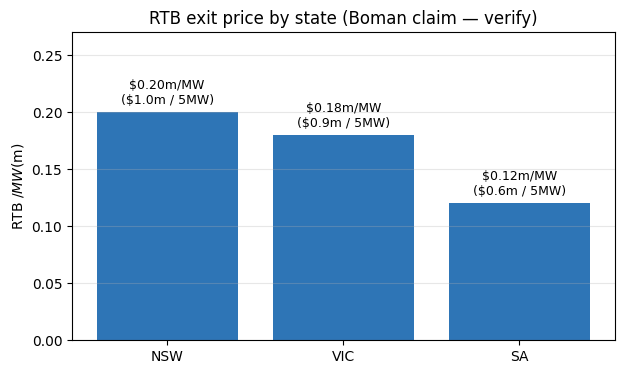

In [3]:
rtb = pd.read_csv('../data/processed/rtb_comps.csv', skiprows=1)  # row 0 is a comment
fig, ax = plt.subplots()
ax.bar(rtb['state'], rtb['price_per_mw_m'], color=ACCENT)
for i, v in enumerate(rtb['price_per_mw_m']):
    ax.annotate(f'${v:.2f}m/MW\n(${v*5:.1f}m / 5MW)', (i, v), textcoords='offset points',
                xytext=(0, 6), ha='center', fontsize=9)
ax.set_ylabel('RTB $/MW ($m)'); ax.set_title('RTB exit price by state (Boman claim — verify)')
ax.set_ylim(0, rtb['price_per_mw_m'].max()*1.35); ax.grid(axis='y', alpha=.3)
plt.show()

## 3. Where the margin is — RTB as a % of built-asset value

A useful sense-check: RTB should be a *small slice* (~10–12%) of the eventual built-asset value, confirming this is the early-stage development premium — not the construction value (which the **buyer** funds).

In [4]:
rv = ve.rtb_vs_built(inp)
pd.DataFrame([{'state': k, 'RTB $/MW': v['rtb_per_mw'], 'Built $/MW': v['built_per_mw'],
               'RTB % of built': f"{v['pct_of_built']:.0%}"} for k, v in rv.items()])

,state,RTB $/MW,Built $/MW,RTB % of built
0,NSW,0.20,1.8,11%
1,VIC,0.18,1.8,10%
2,SA,0.12,1.8,7%


## 4. Industry frameworks (develop-and-flip lens)

More detail is in the industry write-up [`../INDUSTRY_REPORT.md`](../INDUSTRY_REPORT.md). Headlines:

- **Life cycle — growth.** A *tailwind* for develop-and-flip (rising demand = more buyers), not the buy-and-hold "yellow flag." *(Boman cites ~26% BESS CAGR to 2030 — verify against AEMO ISP.)*
- **Porter — on the RTB market** (not the electricity market): **buyer power** (finite, non-binding pool) and **new entrants/rivalry** (is the 5 MW niche genuinely under-contested?) are the crux.
- **PESTLE:** policy dependency is the big risk; the **sub-5 MW exemption** is the regulatory edge.
- **PE/fund screen:** recurring-revenue problem **sidestepped** (sells pre-operation); **clear exit path** is THE criterion; development is **capital-light** (~$0.5m/project vs $8–10m to build).

## 5. Execution risk — the survival curve (independent, public data)

The first make-or-break: can projects clear planning → grid connection → sale on schedule? Decomposed from public data, the **independent cumulative success is ~45%** — which sits **below** Boman's Base case (65%).

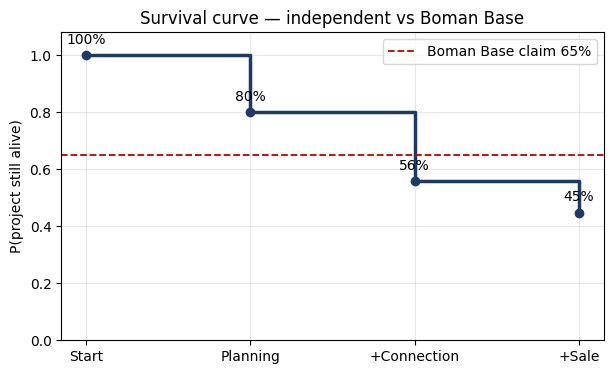

Independent cumulative ~45% vs Boman Base 65%  -> optimism gap +20%


In [5]:
sc = ve.survival_curve(inp)
stages = ['Start', 'Planning', '+Connection', '+Sale']
surv = [1.0, sc['survival_after_planning'], sc['survival_after_connection'], sc['cumulative']]
fig, ax = plt.subplots()
ax.step(range(4), surv, where='post', color=NAVY, lw=2.5, marker='o')
[ax.annotate(f'{v:.0%}', (i, v), textcoords='offset points', xytext=(0, 8), ha='center') for i, v in enumerate(surv)]
ax.axhline(s['base_scenario_success'], color=RED, ls='--', lw=1.3,
           label=f"Boman Base claim {s['base_scenario_success']:.0%}")
ax.set_xticks(range(4)); ax.set_xticklabels(stages); ax.set_ylim(0, 1.08)
ax.set_ylabel('P(project still alive)'); ax.set_title('Survival curve — independent vs Boman Base')
ax.legend(); ax.grid(alpha=.3); plt.show()
print(f"Independent cumulative ~{sc['cumulative']:.0%} vs Boman Base {s['base_scenario_success']:.0%}"
      f"  -> optimism gap {s['optimism_gap']:+.0%}")

## 6. Exit risk — the buyer landscape (the decisive section)

A flip with no buyer is a stranded asset. The buyer pool for Australian battery assets is deep and well-funded — **IPPs / developers, infrastructure funds** (Palisade/Intera, CIP, Quinbrook), **super funds** (Aware Super, HESTA), **government green capital** (CEFC, ESC) and **retailers** (Origin, AGL, EnergyAustralia). Two cautions dominate:

1. **Bindingness** — Boman's "3 interested buyers" are **non-binding**.
2. **Stage mismatch** — capital increasingly pays up for *de-risked, contracted, construction-ready* assets, whereas this fund sells *earlier-stage, uncontracted RTB*. The RTB buyer market specifically must be deep and durable.

## 7. Verdict — the single biggest risk

A real, policy-backed, capital-light niche with a viable RTB exit — **but conditional**. The single biggest risk is **exit / buyer risk** (non-binding buyers; RTB stage), closely followed by **development / approval risk** (the survival curve), with **success-rate optimism** (Base 65% vs independent ~45%) a third. Note what is *not* the main risk: **merchant-price volatility**, which passes to the buyer.

→ The valuation rebuild quantifies all this: see **notebook 02** and the Excel model.